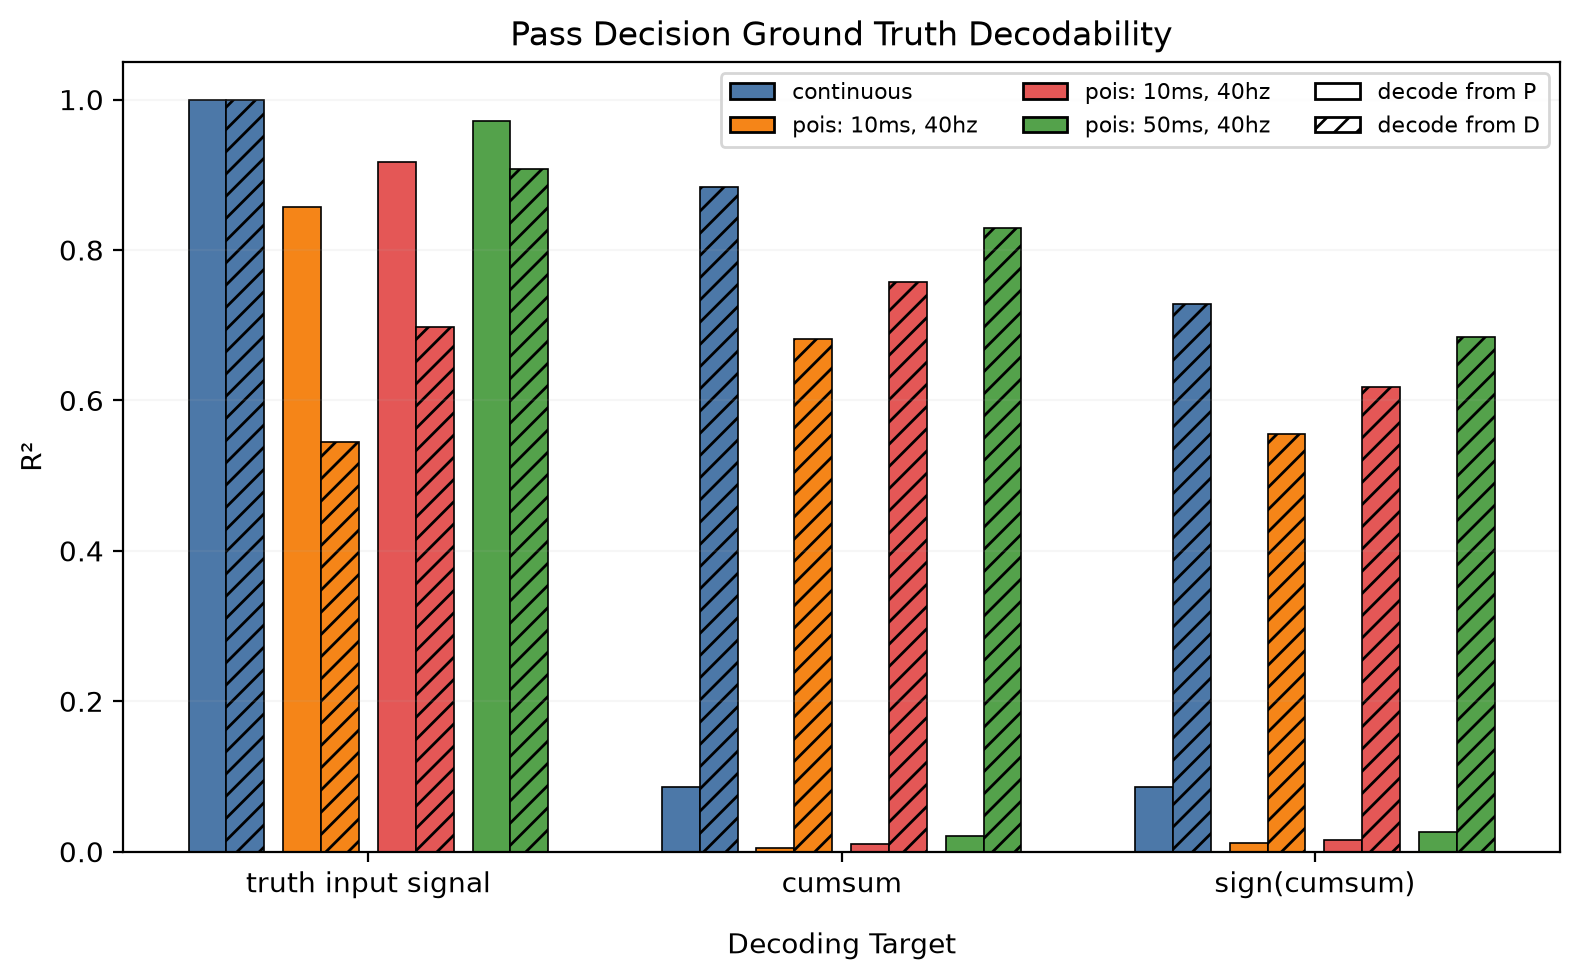

In [52]:
# Visualize dataset ground truth decodability

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv(
    "../data/pass_decision_h256_n0.001_seed0_id2607210153/pd_decodability_results.csv"
)

score_cols = [
    "score_continuous",
    "score_poisson_dt0.01_rate20",
    "score_poisson_dt0.01_rate40",
    "score_poisson_dt0.05_rate40",
]

labels = ["continuous", "pois: 10ms, 40hz", "pois: 10ms, 40hz", "pois: 50ms, 40hz"]
colors = ["#4C78A8", "#F58518", "#E45756", "#54A24B"]
hatches = {"P": "", "D": "///"}

targets = list(df["target"].unique())
areas = ["P", "D"]
x = np.arange(len(targets))
width = 0.08
group_gap = 0.04
cluster = len(areas) * width + group_gap
total = len(score_cols) * cluster - group_gap

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)

for j, (col, lab, c) in enumerate(zip(score_cols, labels, colors)):
    for i, area in enumerate(areas):
        sub = df[df["decode_from"] == area].set_index("target")

        offset = -total / 2 + j * cluster + i * width + width / 2
        vals = [sub.loc[t, col] for t in targets]
        ax.bar(
            x + offset,
            vals,
            width,
            color=c,
            hatch=hatches[area],
            edgecolor="black",
            linewidth=0.6,
        )

ax.set_xticks(x)
ax.set_xticklabels(["truth input signal", "cumsum", "sign(cumsum)"])
ax.set_ylabel("R²")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Decoding Target", labelpad=12)
ax.set_title("Pass Decision Ground Truth Decodability")
ax.grid(axis="y", alpha=0.1)


condition_handles = [
    Patch(facecolor=c, edgecolor="black", label=lab)
    for c, lab in zip(colors, labels)
]

area_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=hatches[a], label=f"decode from {a}")
    for a in areas
]

ax.legend(
    handles=condition_handles + area_handles,
    fontsize=8,
    ncols=3,
    loc="upper right",
)
plt.tight_layout()
plt.show()

In [ ]:
# Plot loss curves

from pathlib import Path
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

run = Path("../data/pass_decision_h256_n0.001_seed0_id2607210153")
ea = EventAccumulator(str(next(run.glob("events.out.tfevents*"))), size_guidance={"scalars": 0})
ea.Reload()

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
for tag in ("train/loss", "valid/loss"):
    s = ea.Scalars(tag)
    ax.plot([x.step for x in s], [x.value for x in s], label=tag)

ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title(run.name)
ax.legend()
plt.tight_layout()
plt.show()

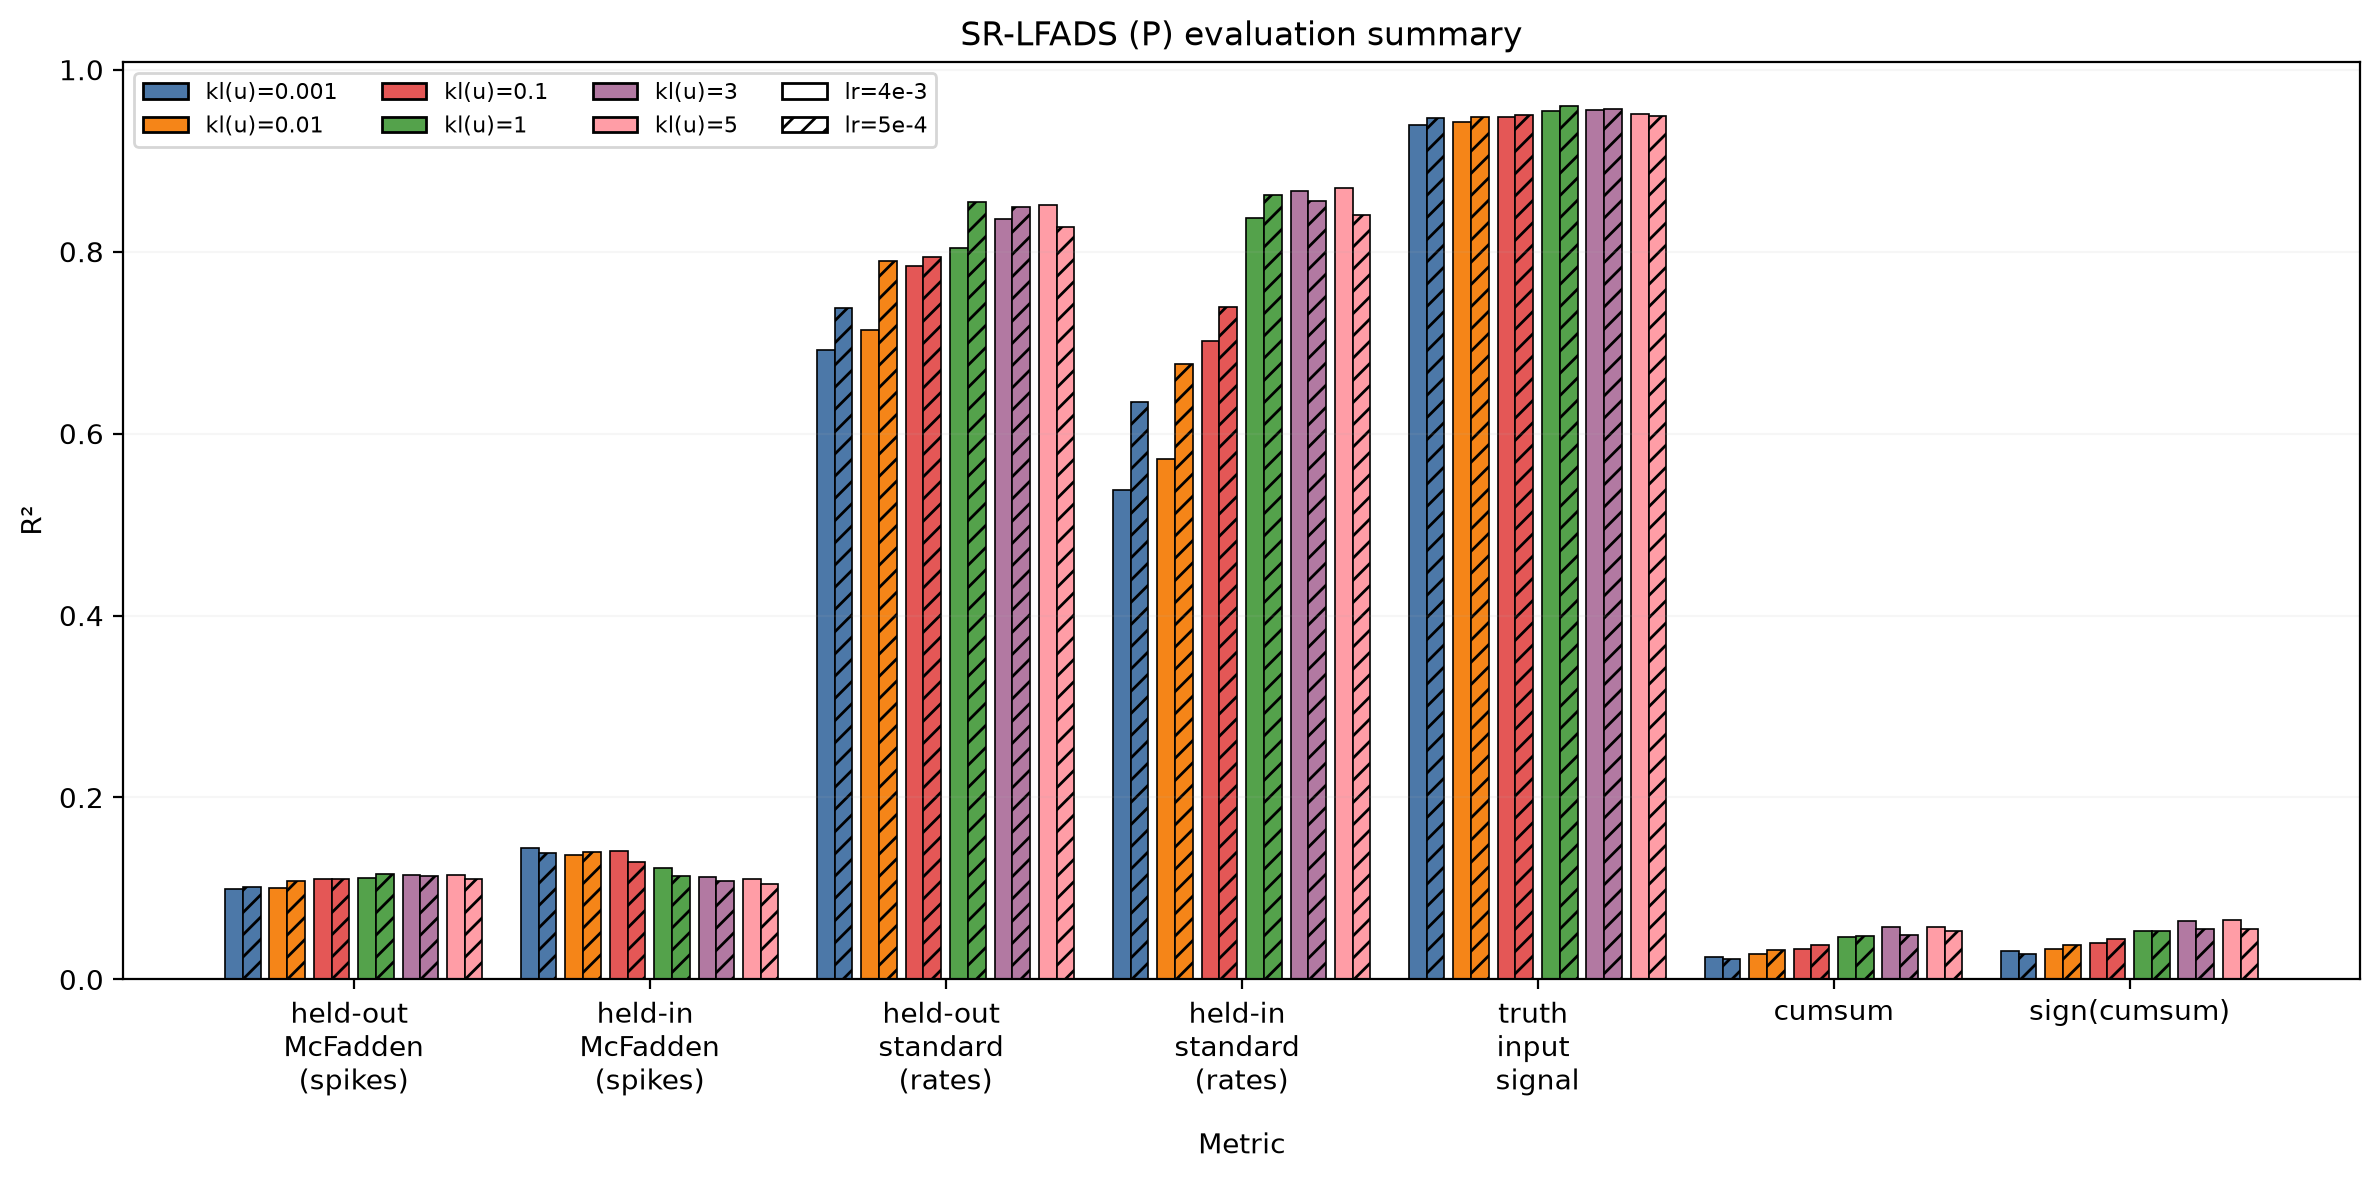

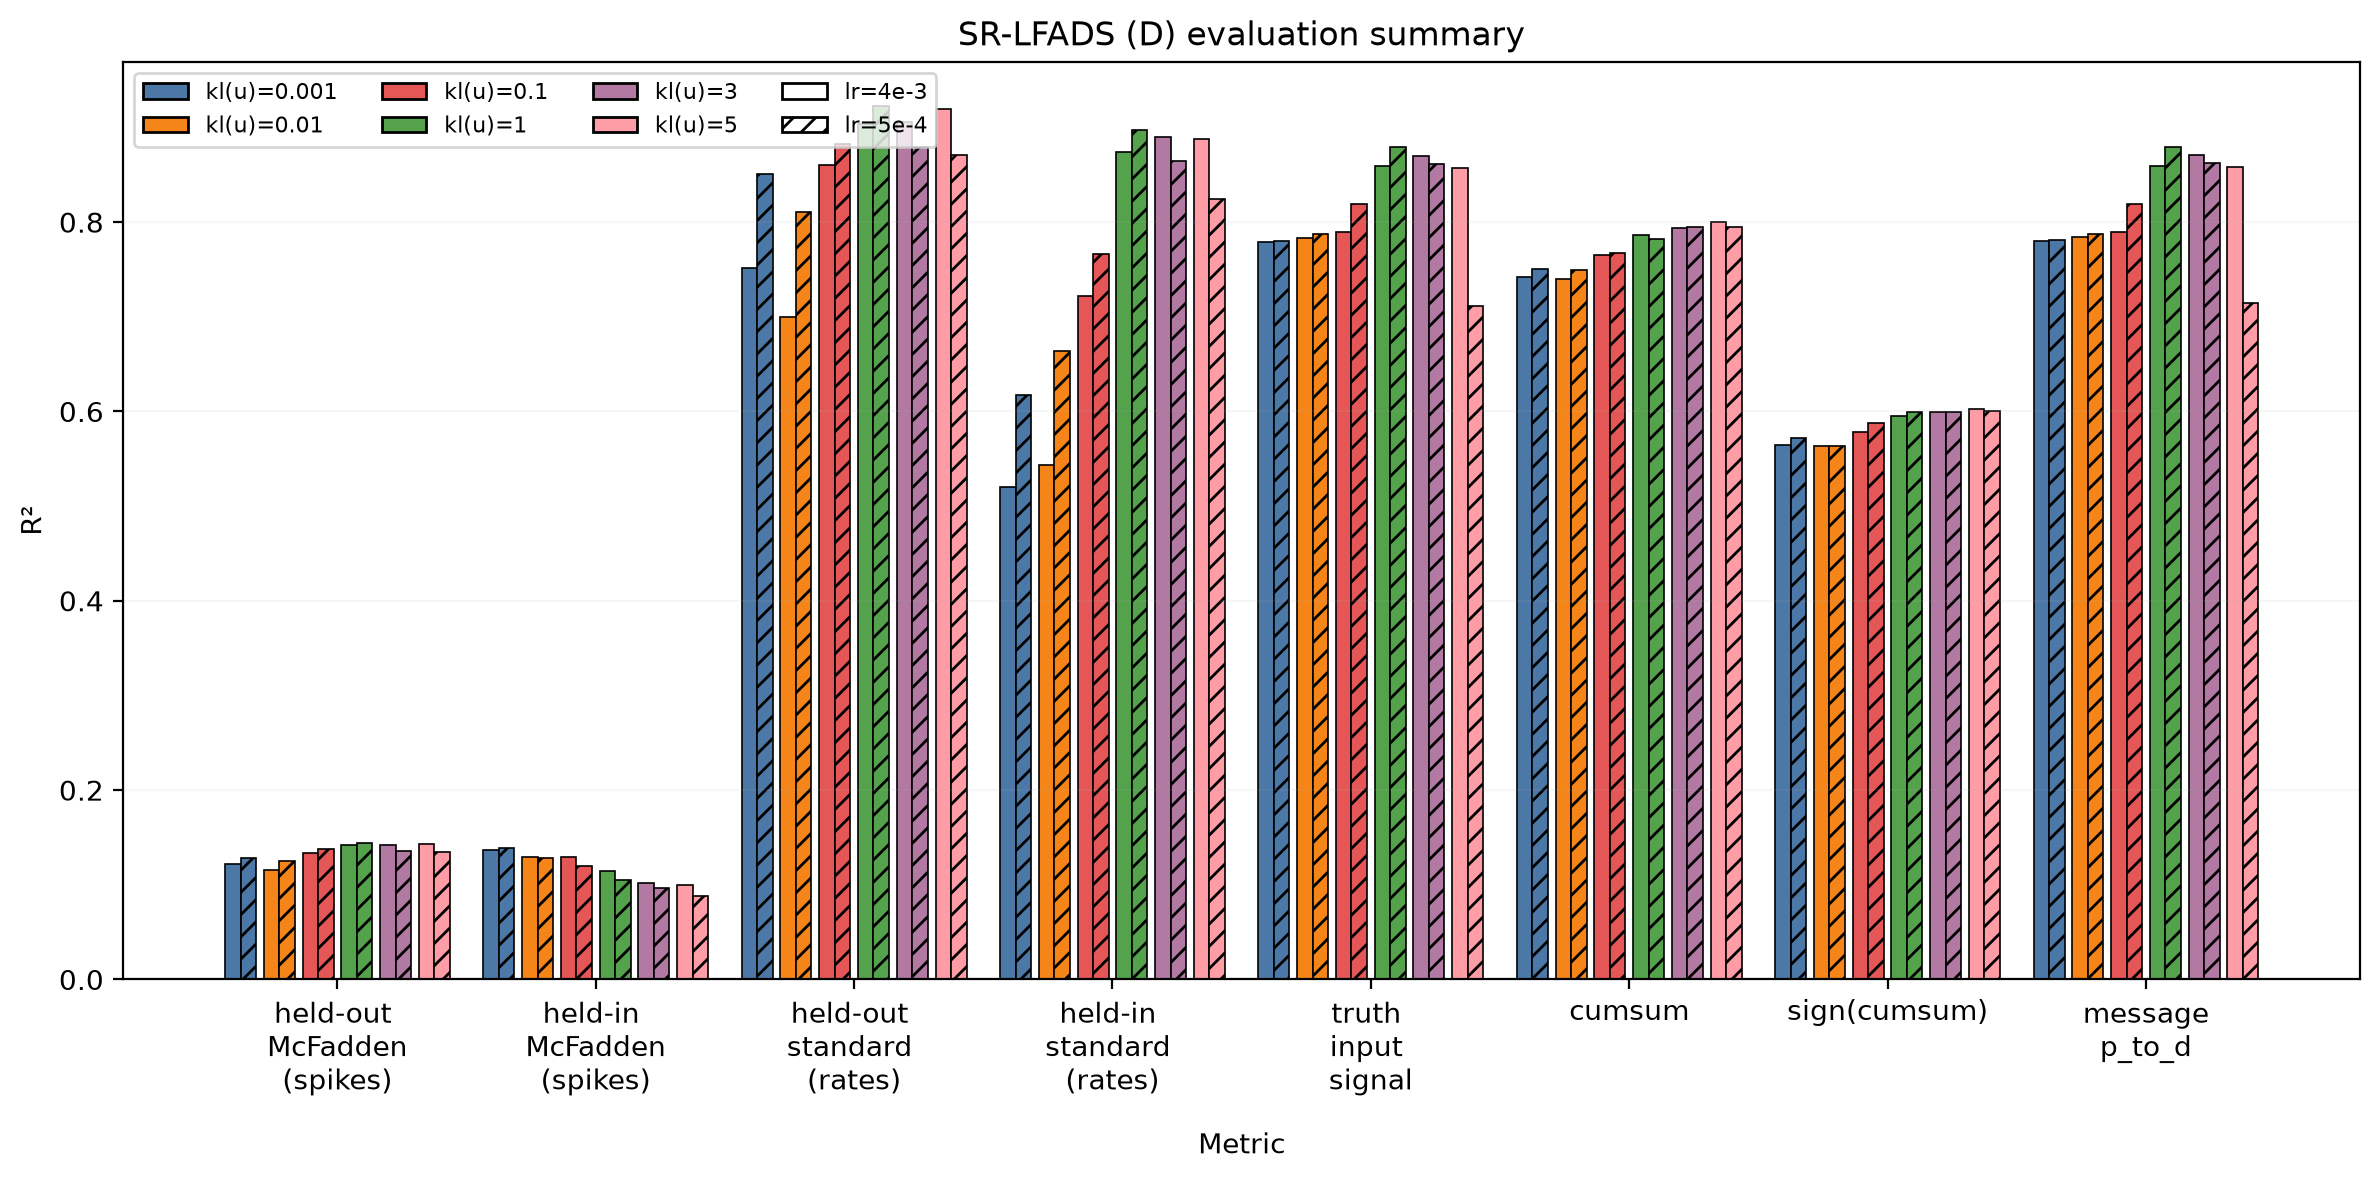

In [82]:
# Visualize SR-LFADS (P / D) metrics

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def parse_kl(run: str) -> float:
    m = re.search(r"_kl(\d+)", run)
    raw = m.group(1)
    # kl0001->0.001, kl001->0.01, kl01->0.1, kl1->1, kl3->3, ...
    if raw.startswith("0"):
        return int(raw) / 10 ** (len(raw) - 1)
    return float(raw)

BASE_METRIC_ORDER = [
    ("r2-held-out-mcfadden-mean", "held-out \nMcFadden\n(spikes)"),
    ("r2-held-in-mcfadden-mean", "held-in \nMcFadden\n(spikes)"),
    ("r2-held-out-rates-mean", "held-out \nstandard \n(rates)"),
    ("r2-held-in-rates-mean", "held-in \nstandard \n(rates)"),
    ("truth-inp-decode-r2-mean", "truth \ninput \nsignal"),
    ("cumsum-decode-r2-mean", "cumsum"),
    ("sign_cumsum-decode-r2-mean", "sign(cumsum)"),
]
EXTRA_METRICS = {
    "message-p_to_d-decode-r2-mean": "message\np_to_d",
}
COLORS = ["#4C78A8", "#F58518", "#E45756", "#54A24B", "#B279A2", "#FF9DA6"]
HATCHES = {False: "", True: "///"}  # lr=4e-3 solid, lr=5e-4 hatched


def plot_srlfads_summary(csv_path: str, title: str):
    df = pd.read_csv(csv_path)
    df["has_lr"] = df["run"].str.contains("_lr_")
    df["lr"] = np.where(df["has_lr"], 5.0e-4, 4.0e-3)
    df["kl"] = df["run"].map(parse_kl)

    metric_order = list(BASE_METRIC_ORDER)
    for col, lab in EXTRA_METRICS.items():
        if col in df.columns:
            metric_order.append((col, lab))

    metrics = [c for c, _ in metric_order]
    metric_labels = [lab for _, lab in metric_order]

    long = df.melt(
        id_vars=["run", "has_lr", "lr", "kl"],
        value_vars=metrics,
        var_name="metric",
        value_name="score",
    )

    kls = sorted(long["kl"].unique())
    kl_color = dict(zip(kls, COLORS[: len(kls)]))

    x = np.arange(len(metrics))
    width = 0.06
    group_gap = 0.03
    cluster = 2 * width + group_gap
    total = len(kls) * cluster - group_gap

    fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
    for j, kl in enumerate(kls):
        for i, has_lr in enumerate([False, True]):
            sub = long[(long["kl"] == kl) & (long["has_lr"] == has_lr)].set_index("metric")
            offset = -total / 2 + j * cluster + i * width + width / 2
            vals = [sub.loc[m, "score"] for m in metrics]
            ax.bar(
                x + offset,
                vals,
                width,
                color=kl_color[kl],
                hatch=HATCHES[has_lr],
                edgecolor="black",
                linewidth=0.6,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel("R²")
    ax.set_xlabel("Metric", labelpad=12)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.1)

    condition_handles = [
        Patch(facecolor=kl_color[k], edgecolor="black", label=f"kl(u)={k:g}") for k in kls
    ]
    lr_handles = [
        Patch(facecolor="white", edgecolor="black", hatch="", label="lr=4e-3"),
        Patch(facecolor="white", edgecolor="black", hatch="///", label="lr=5e-4"),
    ]
    ax.legend(
        handles=condition_handles + lr_handles,
        fontsize=8,
        ncols=4,
        loc="upper left",
    )
    plt.tight_layout()
    plt.show()


plot_srlfads_summary(
    "../eval_outputs/pd_pois_p/evaluation_summary_all_runs.csv",
    "SR-LFADS (P) evaluation summary",
)

plot_srlfads_summary(
    "../eval_outputs/pd_pois_d/evaluation_summary_all_runs.csv",
    "SR-LFADS (D) evaluation summary",
)
